In [3]:
import os

# Search for .mat files on Desktop
for root, dirs, files in os.walk(os.path.expanduser('~/OneDrive/Desktop')):
    for file in files:
        if file.endswith('.mat'):
            print(os.path.join(root, file))

C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\B007_1_123.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\B014_1_190.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\B021_1_227.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\IR007_1_110.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\IR014_1_175.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\IR021_1_214.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\OR007_6_1_136.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\OR014_6_1_202.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\OR021_6_1_239.mat
C:\Users\lenovo/OneDrive/Desktop\bearing_data\raw\Time_Normal_1_098.mat


In [4]:
from scipy.io import loadmat

# Using the EXACT paths and filenames from your computer
base = r'C:\Users\lenovo\OneDrive\Desktop\bearing_data\raw\\'

normal = loadmat(base + 'Time_Normal_1_098.mat')
ball   = loadmat(base + 'B007_1_123.mat')
inner  = loadmat(base + 'IR007_1_110.mat')
outer  = loadmat(base + 'OR007_6_1_136.mat')

print("Normal keys:", [k for k in normal.keys() if not k.startswith('_')])
print("Ball keys:",   [k for k in ball.keys()   if not k.startswith('_')])
print("Inner keys:",  [k for k in inner.keys()  if not k.startswith('_')])
print("Outer keys:",  [k for k in outer.keys()  if not k.startswith('_')])

Normal keys: ['X098_DE_time', 'X098_FE_time']
Ball keys: ['X123_DE_time', 'X123_FE_time', 'X123RPM']
Inner keys: ['X110_DE_time', 'X110_FE_time', 'X110RPM']
Outer keys: ['X136_DE_time', 'X136_FE_time', 'X136RPM']


✅ Normal signal length: 483903
✅ Ball signal length:   487384
✅ Inner signal length:  486224
✅ Outer signal length:  486804


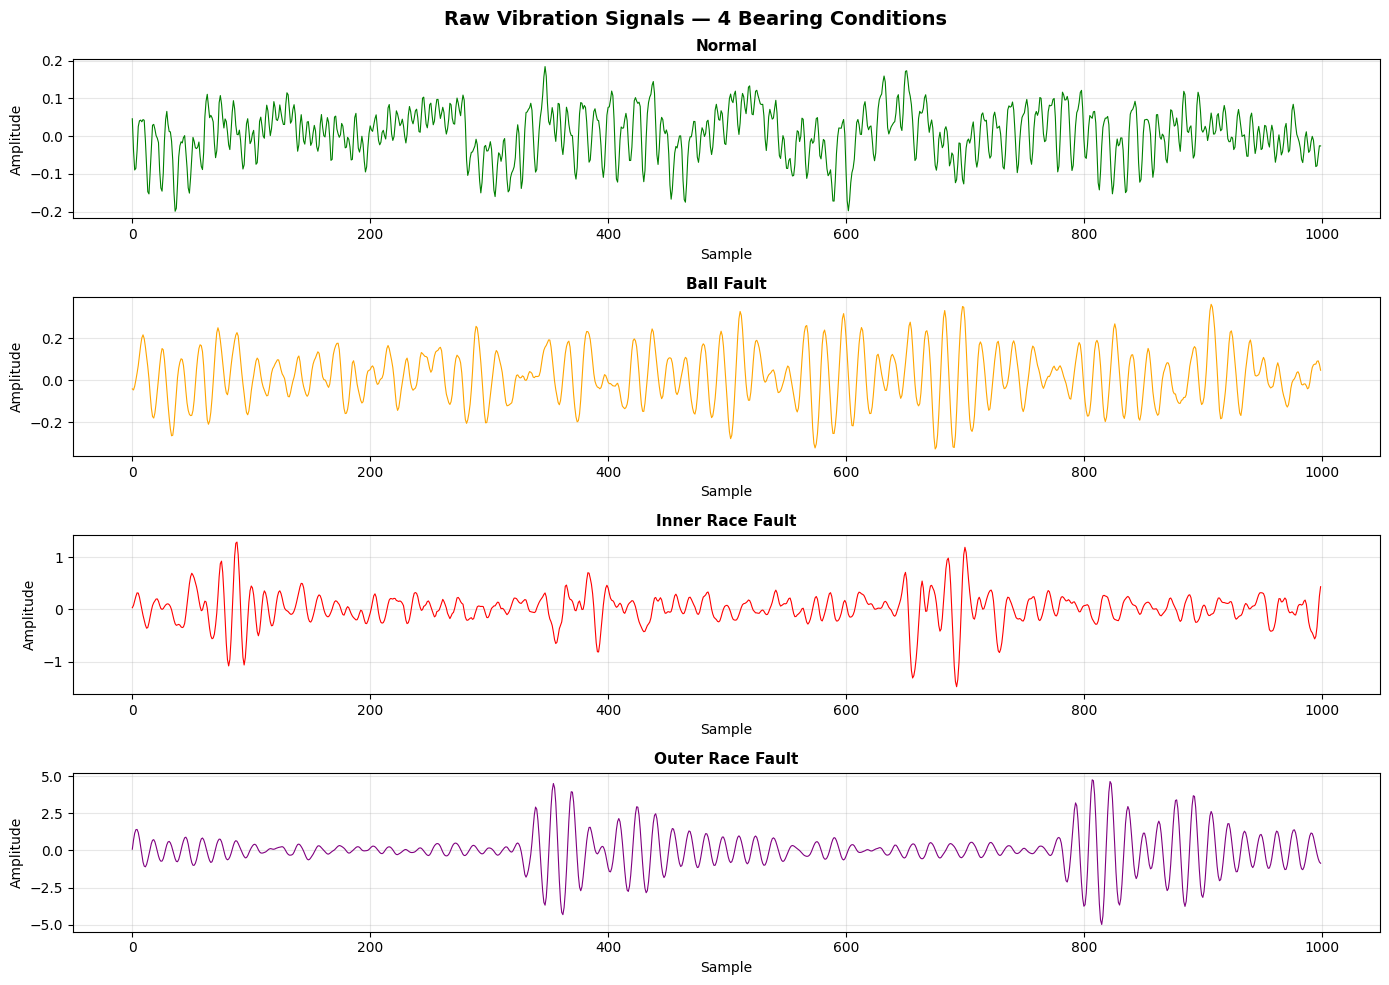

✅ Day 1 complete! plot1_raw_signals.png saved!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

base = r'C:\Users\lenovo\OneDrive\Desktop\bearing_data\raw\\'

# Load files
normal = loadmat(base + 'Time_Normal_1_098.mat')
ball   = loadmat(base + 'B007_1_123.mat')
inner  = loadmat(base + 'IR007_1_110.mat')
outer  = loadmat(base + 'OR007_6_1_136.mat')

# Extract signals using YOUR exact key names
normal_signal = normal['X098_DE_time'].flatten()
ball_signal   = ball['X123_DE_time'].flatten()
inner_signal  = inner['X110_DE_time'].flatten()
outer_signal  = outer['X136_DE_time'].flatten()

print(f"✅ Normal signal length: {len(normal_signal)}")
print(f"✅ Ball signal length:   {len(ball_signal)}")
print(f"✅ Inner signal length:  {len(inner_signal)}")
print(f"✅ Outer signal length:  {len(outer_signal)}")

# Plot all 4 signals
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

signals = [normal_signal, ball_signal, inner_signal, outer_signal]
labels  = ['Normal', 'Ball Fault', 'Inner Race Fault', 'Outer Race Fault']
colors  = ['green', 'orange', 'red', 'purple']

for ax, signal, label, color in zip(axes, signals, labels, colors):
    ax.plot(signal[:1000], color=color, linewidth=0.8)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

plt.suptitle("Raw Vibration Signals — 4 Bearing Conditions",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_raw_signals.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Day 1 complete! plot1_raw_signals.png saved!")

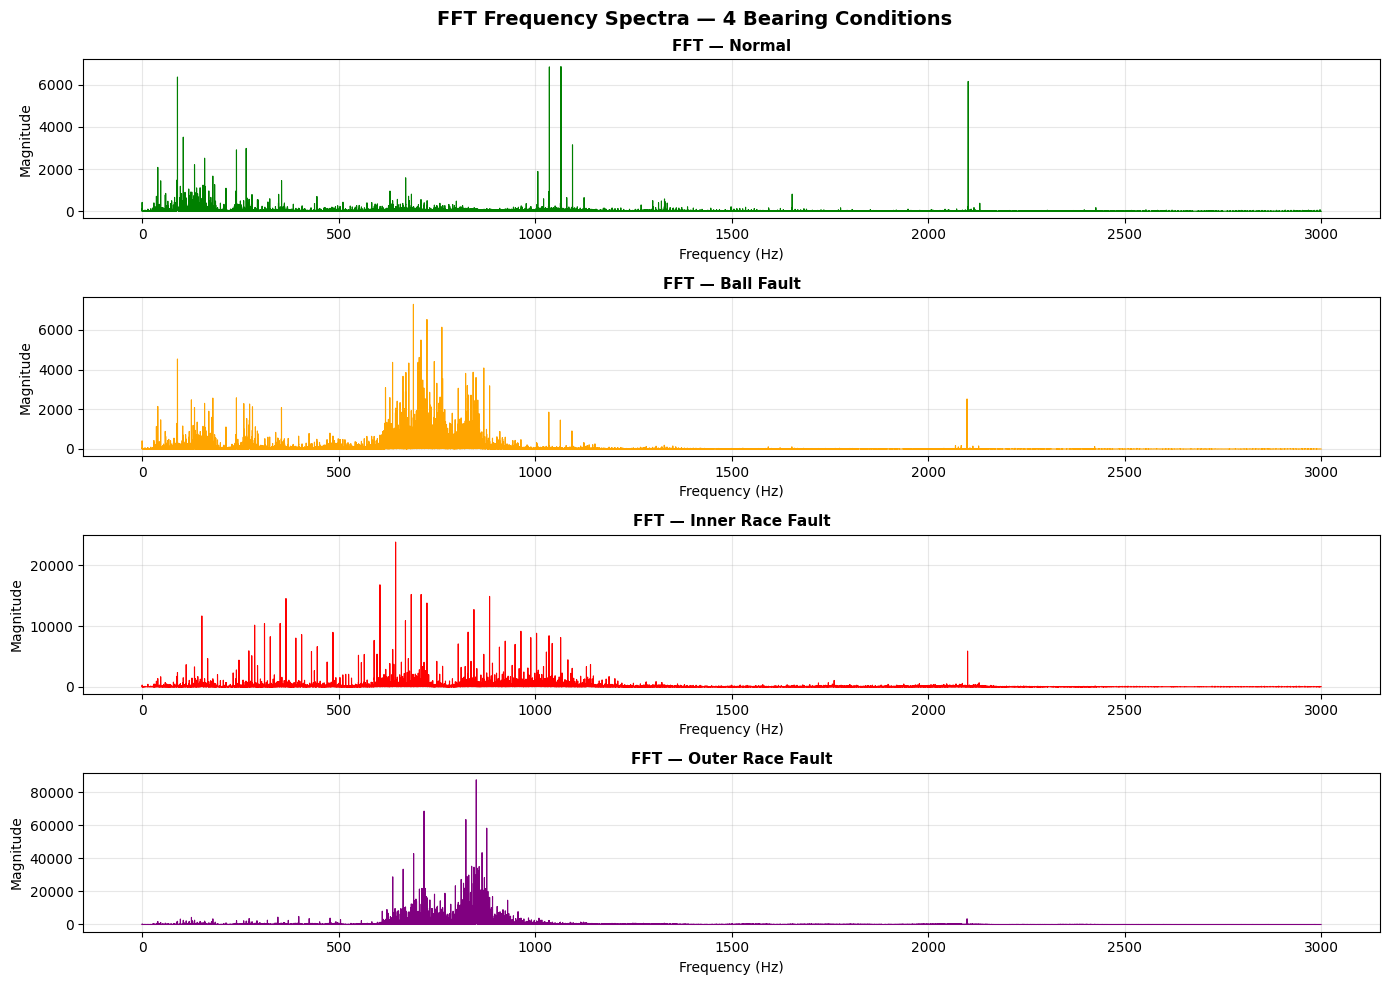

✅ Day 2 fixed! plot2_fft.png saved!


In [7]:
import numpy as np
import matplotlib.pyplot as plt

sampling_rate = 12000

def plot_fft(signal, label, ax, color):
    # Remove DC offset by subtracting mean — this fixes the 0Hz spike
    signal = signal - np.mean(signal)
    N = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs    = np.fft.rfftfreq(N, d=1/sampling_rate)
    
    # Show 0 to 3000 Hz — this is where bearing faults appear
    mask = freqs <= 3000
    ax.plot(freqs[mask], fft_vals[mask], color=color, linewidth=0.8)
    ax.set_title(f"FFT — {label}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

signals = [normal_signal, ball_signal, inner_signal, outer_signal]
labels  = ['Normal', 'Ball Fault', 'Inner Race Fault', 'Outer Race Fault']
colors  = ['green', 'orange', 'red', 'purple']

for ax, sig, lbl, col in zip(axes, signals, labels, colors):
    plot_fft(sig, lbl, ax, col)

plt.suptitle("FFT Frequency Spectra — 4 Bearing Conditions",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_fft.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Day 2 fixed! plot2_fft.png saved!")

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

def extract_features(signal, segment_size=1024):
    features = []
    num_segments = len(signal) // segment_size
    
    for i in range(num_segments):
        seg = signal[i*segment_size : (i+1)*segment_size]
        feature_row = {
            'mean':     np.mean(seg),
            'std':      np.std(seg),
            'rms':      np.sqrt(np.mean(seg**2)),
            'peak':     np.max(np.abs(seg)),
            'kurtosis': kurtosis(seg),
            'skewness': skew(seg),
            'crest':    np.max(np.abs(seg)) / (np.sqrt(np.mean(seg**2)) + 1e-9),
            'energy':   np.sum(seg**2)
        }
        features.append(feature_row)
    return pd.DataFrame(features)

# Extract features for all 4 conditions
df_normal = extract_features(normal_signal); df_normal['label'] = 0
df_ball   = extract_features(ball_signal);   df_ball['label']   = 1
df_inner  = extract_features(inner_signal);  df_inner['label']  = 2
df_outer  = extract_features(outer_signal);  df_outer['label']  = 3

# Combine into one dataset
df = pd.concat([df_normal, df_ball, df_inner, df_outer], ignore_index=True)

print(f"✅ Dataset shape: {df.shape}")
print(f"\nSamples per class:")
print(df['label'].value_counts().sort_index())
print(f"\nFirst 5 rows:")
print(df.head())

# Save for Day 4
df.to_csv('bearing_features.csv', index=False)
print("\n✅ Day 3 complete! bearing_features.csv saved!")

✅ Dataset shape: (1896, 9)

Samples per class:
label
0    472
1    475
2    474
3    475
Name: count, dtype: int64

First 5 rows:
       mean       std       rms      peak  kurtosis  skewness     crest  \
0  0.005364  0.065107  0.065328  0.198810 -0.082419 -0.373705  3.043269   
1  0.010640  0.067653  0.068484  0.204234 -0.293267 -0.202203  2.982204   
2  0.009911  0.062318  0.063101  0.204443  0.154834 -0.257880  3.239937   
3  0.009280  0.063649  0.064322  0.182330 -0.176574 -0.285277  2.834656   
4  0.010609  0.063624  0.064503  0.204860 -0.214526 -0.115693  3.176002   

     energy  label  
0  4.370165      0  
1  4.802676      0  
2  4.077289      0  
3  4.236573      0  
4  4.260437      0  

✅ Day 3 complete! bearing_features.csv saved!


  Logistic Regression Accuracy: 99.47%
  Random Forest Accuracy:       100.00%


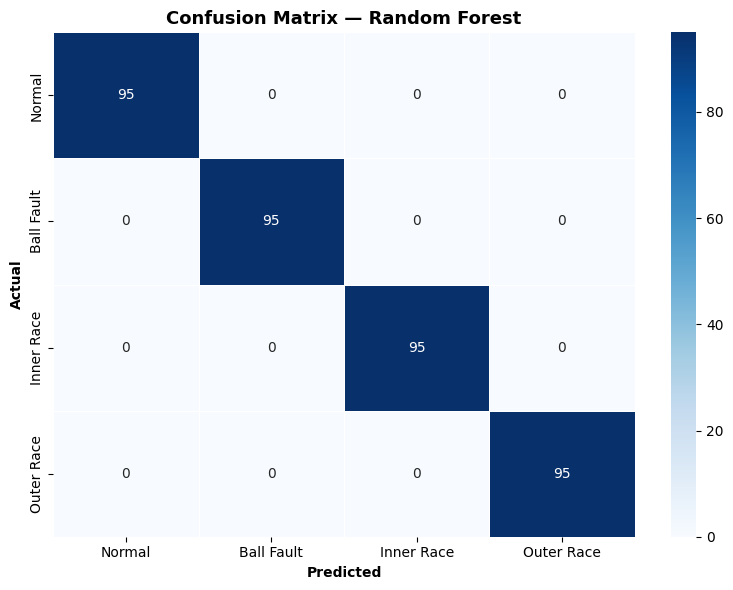

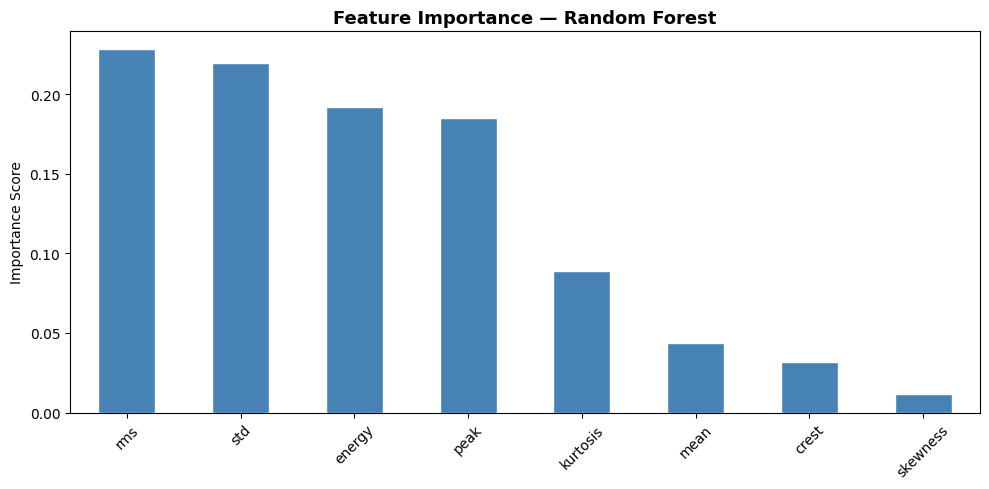


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        95
  Ball Fault       1.00      1.00      1.00        95
  Inner Race       1.00      1.00      1.00        95
  Outer Race       1.00      1.00      1.00        95

    accuracy                           1.00       380
   macro avg       1.00      1.00      1.00       380
weighted avg       1.00      1.00      1.00       380

✅ Day 4 complete! All plots saved!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load features
df = pd.read_csv('bearing_features.csv')
X = df.drop('label', axis=1)
y = df['label']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ---- Model 1: Logistic Regression ----
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))

# ---- Model 2: Random Forest ----
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
rf_preds = rf.predict(X_test_sc)
rf_acc   = accuracy_score(y_test, rf_preds)

print("="*45)
print(f"  Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"  Random Forest Accuracy:       {rf_acc*100:.2f}%")
print("="*45)

# ---- Confusion Matrix ----
labels_map = ['Normal', 'Ball Fault', 'Inner Race', 'Outer Race']
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_map, yticklabels=labels_map,
            linewidths=0.5)
plt.title("Confusion Matrix — Random Forest", fontsize=13, fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Feature Importance ----
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Feature Importance — Random Forest", fontsize=13, fontweight='bold')
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot4_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Full Report ----
print("\nDetailed Classification Report:")
print(classification_report(y_test, rf_preds, target_names=labels_map))
print("✅ Day 4 complete! All plots saved!")

In [11]:
import os
print("Plots are saved in:", os.getcwd())

Plots are saved in: C:\Users\lenovo\OneDrive\Desktop\bearing_data\raw
